# Imports

In [ ]:
import json
import re
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import nltk
import pandas as pd
from IPython.display import display
from nltk import pos_tag, pos_tag_sents, sent_tokenize, word_tokenize
from nltk.stem import WordNetLemmatizer
from tqdm.auto import tqdm

# Загружаем ресурсы NLTK для токенизации, разметки и лемматизации.
NLTK_RESOURCES = {
    "tokenizers/punkt_tab": "punkt_tab",
    "taggers/averaged_perceptron_tagger_eng": ("averaged_perceptron_tagger_eng"),
    "corpora/wordnet": "wordnet",
}
for resource_path, resource_name in NLTK_RESOURCES.items():
    try:
        nltk.data.find(resource_path)
    except LookupError:
        nltk.download(resource_name, quiet=True)

POS_CACHE_PATH = Path("../TMP/data/lab2_pos_results.json")

# Фиксируем параметры анализа и признаки целевых местоимений.
RANDOM_STATE = 42
PATTERN_DOCUMENTS_PER_CLASS = 1000
TAGGER_ERROR_EXAMPLES = 5
PRONOUN_FEATURES = {
    "he": ("singular", "masculine"),
    "she": ("singular", "feminine"),
    "they": ("plural", "unknown"),
    "it": ("singular", "neutral"),
    "this": ("singular", "neutral"),
}
MASCULINE_NOUNS = {
    "boy",
    "brother",
    "father",
    "gentleman",
    "husband",
    "king",
    "man",
    "mr",
    "president",
    "son",
}
FEMININE_NOUNS = {
    "daughter",
    "girl",
    "lady",
    "mother",
    "mrs",
    "ms",
    "queen",
    "sister",
    "wife",
    "woman",
}
lemmatizer = WordNetLemmatizer()

# 1. Частеречная разметка (POS-tagging)

Загружаем оба класса новостей, добавляем метки и объединяем их в единый корпус.

In [2]:
# Загружаем исходные тексты без изменения их содержания.
true_news_df = pd.read_csv(
    r"..\data\misinformation_n_fake_news\DataSet_Misinfo_TRUE.csv",
    index_col=0,
)
fake_news_df = pd.read_csv(
    r"..\data\misinformation_n_fake_news\DataSet_Misinfo_FAKE.csv",
    index_col=0,
)

# Объединяем непустые документы и сохраняем класс каждого текста.
true_news_df["class"] = "TRUE"
fake_news_df["class"] = "FAKE"
news_df = pd.concat(
    [true_news_df, fake_news_df], ignore_index=True
).dropna(subset=["text"])
news_df["text"] = news_df["text"].astype(str)

print("Количество документов:", len(news_df))
display(news_df["class"].value_counts().rename("Документов").to_frame())

Количество документов: 78588


,Документов
class,
FAKE,43642
TRUE,34946


Применяем готовый английский POS-теггер NLTK к нескольким предложениям и выводим пары `токен — Penn Treebank tag`.

In [3]:
# Выбираем три предложения средней длины для демонстрации разметки.
pos_preview = []
for text in news_df["text"]:
    for sentence in sent_tokenize(text):
        tokens = word_tokenize(sentence)
        if 12 <= sum(token.isalpha() for token in tokens) <= 25:
            pos_preview.append((sentence, pos_tag(tokens)))
            break
    if len(pos_preview) == 3:
        break

# Показываем исходное предложение рядом с результатом тэггера.
for sentence_number, (sentence, tagged_tokens) in enumerate(
    pos_preview, start=1
):
    print(f"{sentence_number}. {sentence}")
    display(pd.DataFrame(tagged_tokens, columns=["Токен", "POS-тег"]).T)

1. “Now, Democrats are saying that’s not enough, we need to give the government a pay raise of 10 to 11 percent.


,0,1,2,3,4,5,6,7,8,9,...,17,18,19,20,21,22,23,24,25,26
Токен,“,Now,",",Democrats,are,saying,that,’,s,not,...,government,a,pay,raise,of,10,to,11,percent,.
POS-тег,RB,RB,",",NNPS,VBP,VBG,IN,NNP,VBD,RB,...,NN,DT,NN,NN,IN,CD,TO,CD,NN,.


2. A Justice Department official said the administration will not challenge those rulings.


,0,1,2,3,4,5,6,7,8,9,10,11,12
Токен,A,Justice,Department,official,said,the,administration,will,not,challenge,those,rulings,.
POS-тег,DT,NNP,NNP,NN,VBD,DT,NN,MD,RB,VB,DT,NNS,.


3. It will be an investigation conducted without political influence,” Graham said on CBS’s Face the Nation news program.


,0,1,2,3,4,5,6,7,8,9,...,13,14,15,16,17,18,19,20,21,22
Токен,It,will,be,an,investigation,conducted,without,political,influence,",",...,on,CBS,’,s,Face,the,Nation,news,program,.
POS-тег,PRP,MD,VB,DT,NN,VBD,IN,JJ,NN,",",...,IN,NNP,NNP,VBD,NNP,DT,NNP,NN,NN,.


# 2. Анализ распределения частей речи

Выполняем потоковую POS-разметку всего корпуса: сохраняем только агрегированные частоты, поэтому объём памяти не зависит от числа токенов. Индикатор прогресса показывает скорость и оставшееся время. Одновременно отбираем десять предложений средней длины, а поиск шума прекращаем после пяти разных диагностических примеров.

In [4]:
# Подготавливаем счётчики и ограниченные коллекции примеров.
pos_counts_by_class = {"TRUE": Counter(), "FAKE": Counter()}
medium_sentences = {"TRUE": [], "FAKE": []}
tagger_error_candidates = {}

# Размечаем каждый документ и отображаем скорость обработки корпуса.
documents = news_df[["class", "text"]].itertuples(index=False)
for document_class, text in tqdm(
    documents,
    total=len(news_df),
    desc="POS-разметка",
    unit="док.",
):
    tokens = word_tokenize(text)
    tagged_tokens = pos_tag(tokens)
    pos_counts_by_class[document_class].update(
        tag for token, tag in tagged_tokens if token.isalpha()
    )

    # Собираем пять предложений средней длины от каждого класса.
    if len(medium_sentences[document_class]) < 5:
        for sentence in sent_tokenize(text):
            sentence_tokens = word_tokenize(sentence)
            word_count = sum(token.isalpha() for token in sentence_tokens)
            if 12 <= word_count <= 25:
                medium_sentences[document_class].append(sentence)
                break

    # Прекращаем дорогой поиск шума после пяти разных примеров.
    if len(tagger_error_candidates) < TAGGER_ERROR_EXAMPLES:
        for token_index, (token, tag) in enumerate(tagged_tokens):
            token_lower = token.lower()
            error_type = None
            expected = None
            if token_lower in {"couldn", "didn", "doesn", "wouldn"}:
                error_type = "Разорванное отрицание"
                expected = "Часть модального или вспомогательного глагола"
            elif token_lower == "welll":
                error_type = "Опечатка с повтором буквы"
                expected = "Наречие well (RB)"
            elif token in {"@", "#"}:
                error_type = "Маркер соцсети"
                expected = "Часть упоминания или хештега, не пунктуация"
            elif token_lower in {"http", "https", "pic.twitter.com"}:
                error_type = "Фрагмент URL"
                expected = "Единый служебный токен URL"
            elif re.fullmatch(
                r"[a-z]+(?:[A-Z][A-Za-z0-9]*)+", token
            ):
                error_type = "Склеенный CamelCase"
                expected = "Несколько слов или имя пользователя"
            elif re.search(r"([A-Za-z])\1{2,}", token):
                error_type = "Экспрессивное растяжение"
                expected = "Нормализованная словарная форма"

            if error_type and error_type not in tagger_error_candidates:
                context_start = max(0, token_index - 6)
                context_end = min(len(tokens), token_index + 7)
                tagger_error_candidates[error_type] = {
                    "Тип ошибки": error_type,
                    "Токен": token,
                    "Теггер присвоил": tag,
                    "Ожидаемая интерпретация": expected,
                    "Контекст": " ".join(
                        tokens[context_start:context_end]
                    ),
                }
                if len(tagger_error_candidates) == TAGGER_ERROR_EXAMPLES:
                    break

print("POS-разметка всего корпуса завершена.")

POS-разметка: 100%|██████████| 78588/78588 [1:05:53<00:00, 19.88док./s]  

POS-разметка всего корпуса завершена.


In [ ]:
# Сохраняем агрегированные результаты для повторного использования.
pos_results = {
    "pos_counts_by_class": {
        document_class: dict(counts)
        for document_class, counts in pos_counts_by_class.items()
    },
    "medium_sentences": medium_sentences,
    "tagger_error_candidates": tagger_error_candidates,
}
POS_CACHE_PATH.write_text(
    json.dumps(pos_results, ensure_ascii=False, indent=2),
    encoding="utf-8",
    newline="\n",
)

print("Результаты сохранены")

Результаты сохранены


In [ ]:
# Восстанавливаем результаты полной POS-разметки из локального кеша.
pos_results = json.loads(
    POS_CACHE_PATH.read_text(encoding="utf-8")
)
pos_counts_by_class = {
    document_class: Counter(counts)
    for document_class, counts in pos_results["pos_counts_by_class"].items()
}
medium_sentences = pos_results["medium_sentences"]
tagger_error_candidates = pos_results["tagger_error_candidates"]

print("Результаты POS-разметки восстановлены.")

Строим частотное распределение POS-тегов по всему корпусу и сравниваем нормированные доли укрупнённых частей речи между настоящими и фейковыми новостями.

,POS-тег,Частота
0,NN,5477151
1,IN,4666983
2,NNP,4408298
3,DT,3737774
4,JJ,2535221
5,NNS,2139809
6,VBD,1634921
7,RB,1440644
8,PRP,1375091
9,VB,1309532


Класс,FAKE,TRUE
Часть речи,,
Глаголы,17.336211,17.274933
Междометия,0.033680,0.013286
Местоимения,6.141954,5.505842
Наречия,4.498855,3.770170
Прилагательные,7.400662,7.399215
Существительные,32.730779,33.508100


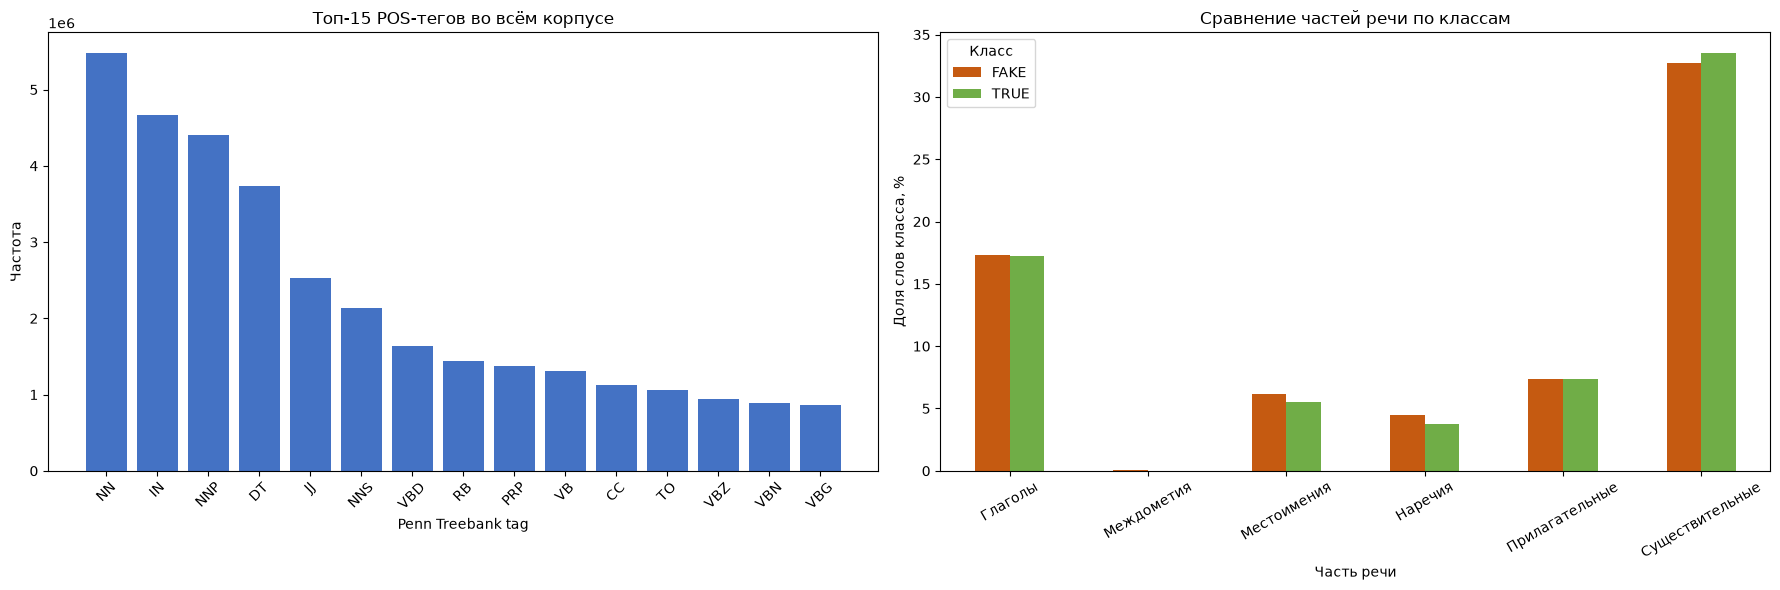

In [12]:
# Объединяем счётчики классов и формируем таблицу топ-тегов.
total_pos_counts = pos_counts_by_class["TRUE"] + pos_counts_by_class["FAKE"]
top_pos_df = pd.DataFrame(
    total_pos_counts.most_common(15), columns=["POS-тег", "Частота"]
)
display(top_pos_df)

# Объединяем близкие Penn-теги в интерпретируемые группы.
pos_groups = {
    "Существительные": ("NN",),
    "Глаголы": ("VB",),
    "Прилагательные": ("JJ",),
    "Наречия": ("RB",),
    "Местоимения": ("PRP", "WP"),
    "Междометия": ("UH",),
}
comparison_rows = []
for document_class, class_counts in pos_counts_by_class.items():
    class_total = sum(class_counts.values())
    for group_name, prefixes in pos_groups.items():
        group_count = sum(
            frequency
            for tag, frequency in class_counts.items()
            if tag.startswith(prefixes)
        )
        comparison_rows.append(
            (document_class, group_name, group_count / class_total * 100)
        )
comparison_df = pd.DataFrame(
    comparison_rows, columns=["Класс", "Часть речи", "Доля, %"]
)
display(comparison_df.pivot(index="Часть речи", columns="Класс", values="Доля, %"))

# Визуализируем общие частоты и межклассовые различия.
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
axes[0].bar(top_pos_df["POS-тег"], top_pos_df["Частота"], color="#4472c4")
axes[0].set_title("Топ-15 POS-тегов во всём корпусе")
axes[0].set_xlabel("Penn Treebank tag")
axes[0].set_ylabel("Частота")
axes[0].tick_params(axis="x", rotation=45)
comparison_df.pivot(
    index="Часть речи", columns="Класс", values="Доля, %"
).plot(kind="bar", ax=axes[1], color=["#c55a11", "#70ad47"])
axes[1].set_title("Сравнение частей речи по классам")
axes[1].set_xlabel("Часть речи")
axes[1].set_ylabel("Доля слов класса, %")
axes[1].tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()

Выводим не менее пяти диагностических примеров. В каждом случае готовый тег относится только к повреждённому токену и потому не передаёт роль исходного слова или служебного объекта.

In [13]:
# Сопоставляем наблюдаемый тег с ожидаемой интерпретацией шумного фрагмента.
tagger_errors_df = pd.DataFrame(tagger_error_candidates.values()).head(
    TAGGER_ERROR_EXAMPLES
)
display(tagger_errors_df)

if len(tagger_errors_df) < TAGGER_ERROR_EXAMPLES:
    print(
        "Автоматически найдено менее пяти разных типов шума; "
        "нужно расширить диагностические правила после просмотра корпуса."
    )

,Тип ошибки,Токен,Теггер присвоил,Ожидаемая интерпретация,Контекст
0,Маркер соцсети,@,NNP,"Часть упоминания или хештега, не пунктуация","my so-called low approval rating , @ foxandfri..."
1,Разорванное отрицание,didn,VBP,Часть модального или вспомогательного глагола,work before Christmas . “ I didn ’ t want you ...
2,Экспрессивное растяжение,KKK,NNP,Нормализованная словарная форма,of the Ku Klux Klan ( KKK ) white supremacist ...
3,Склеенный CamelCase,realDonaldTrump,NN,Несколько слов или имя пользователя,"Good luck with that , @ realDonaldTrump . Neve..."
4,Фрагмент URL,https,NN,Единый служебный токен URL,have some eloquently thought out … https : . —...


# 3. Синтаксический анализ зависимостей (Dependency Parsing)

Строим rule-based деревья зависимостей поверх POS-тегов. Алгоритм выбирает смысловой глагол как корень и назначает связи `nsubj`, `dobj`, `amod`, `advmod`, `det`, `prep` и служебные связи по позиции и части речи токена.

In [14]:
def build_dependency_tree(
    tagged_sentence: list[tuple[str, str]],
) -> pd.DataFrame:
    """
    Строит rule-based дерево зависимостей по POS-разметке предложения.

    Parameters:
        tagged_sentence (list[tuple[str, str]]): Пары токена и POS-тега.

    Returns:
        pd.DataFrame: Таблица токенов, вершин-родителей и типов связей.

    Fallbacks:
        Если глагола нет, корнем становится первое существительное или токен.
    """
    # Выбираем смысловой глагол, пропуская вспомогательный при наличии альтернативы.
    auxiliary_lemmas = {"be", "do", "have"}
    verb_indices = [
        index
        for index, (_, tag) in enumerate(tagged_sentence)
        if tag.startswith("VB")
    ]
    lexical_verbs = [
        index
        for index in verb_indices
        if lemmatizer.lemmatize(tagged_sentence[index][0].lower(), "v")
        not in auxiliary_lemmas
    ]
    noun_indices = [
        index
        for index, (_, tag) in enumerate(tagged_sentence)
        if tag.startswith("NN")
    ]
    root_index = (
        lexical_verbs[0]
        if lexical_verbs
        else verb_indices[0]
        if verb_indices
        else noun_indices[0]
        if noun_indices
        else 0
    )

    # Считаем ближайшее существительное или местоимение слева подлежащим.
    subject_candidates = [
        index
        for index, (_, tag) in enumerate(tagged_sentence[:root_index])
        if tag.startswith("NN") or tag in {"PRP", "WP"}
    ]
    subject_index = subject_candidates[-1] if subject_candidates else None
    dependency_rows = []

    # Назначаем каждому токену единственного родителя и тип связи.
    for token_index, (token, tag) in enumerate(tagged_sentence):
        head_index = root_index
        relation = "dep"
        if token_index == root_index:
            head_index = -1
            relation = "root"
        elif token_index == subject_index:
            relation = "nsubj"
        elif re.fullmatch(r"[^\w\s]+", token):
            relation = "punct"
        elif tag in {"DT", "PDT", "WDT"}:
            following_nouns = [index for index in noun_indices if index > token_index]
            head_index = following_nouns[0] if following_nouns else root_index
            relation = "det"
        elif tag.startswith("JJ"):
            following_nouns = [index for index in noun_indices if index > token_index]
            head_index = following_nouns[0] if following_nouns else root_index
            relation = "amod" if following_nouns else "acomp"
        elif tag.startswith("RB"):
            head_index = min(
                verb_indices or [root_index],
                key=lambda index: abs(index - token_index),
            )
            relation = "advmod"
        elif tag.startswith("VB"):
            relation = "aux" if token_index < root_index else "conj"
        elif tag.startswith("NN"):
            relation = "compound" if token_index < root_index else "dobj"
            if subject_index is not None and token_index < subject_index:
                head_index = subject_index
        elif tag in {"IN", "TO"}:
            preceding_heads = [
                index
                for index in verb_indices + noun_indices
                if index < token_index
            ]
            head_index = preceding_heads[-1] if preceding_heads else root_index
            relation = "prep"
        elif tag == "CC":
            relation = "cc"

        dependency_rows.append(
            (token_index, token, tag, head_index, relation)
        )

    return pd.DataFrame(
        dependency_rows,
        columns=["index", "token", "pos", "head", "relation"],
    )

Формируем деревья для десяти предложений средней длины — по пять из каждого класса — и визуализируем направленные связи между токенами.

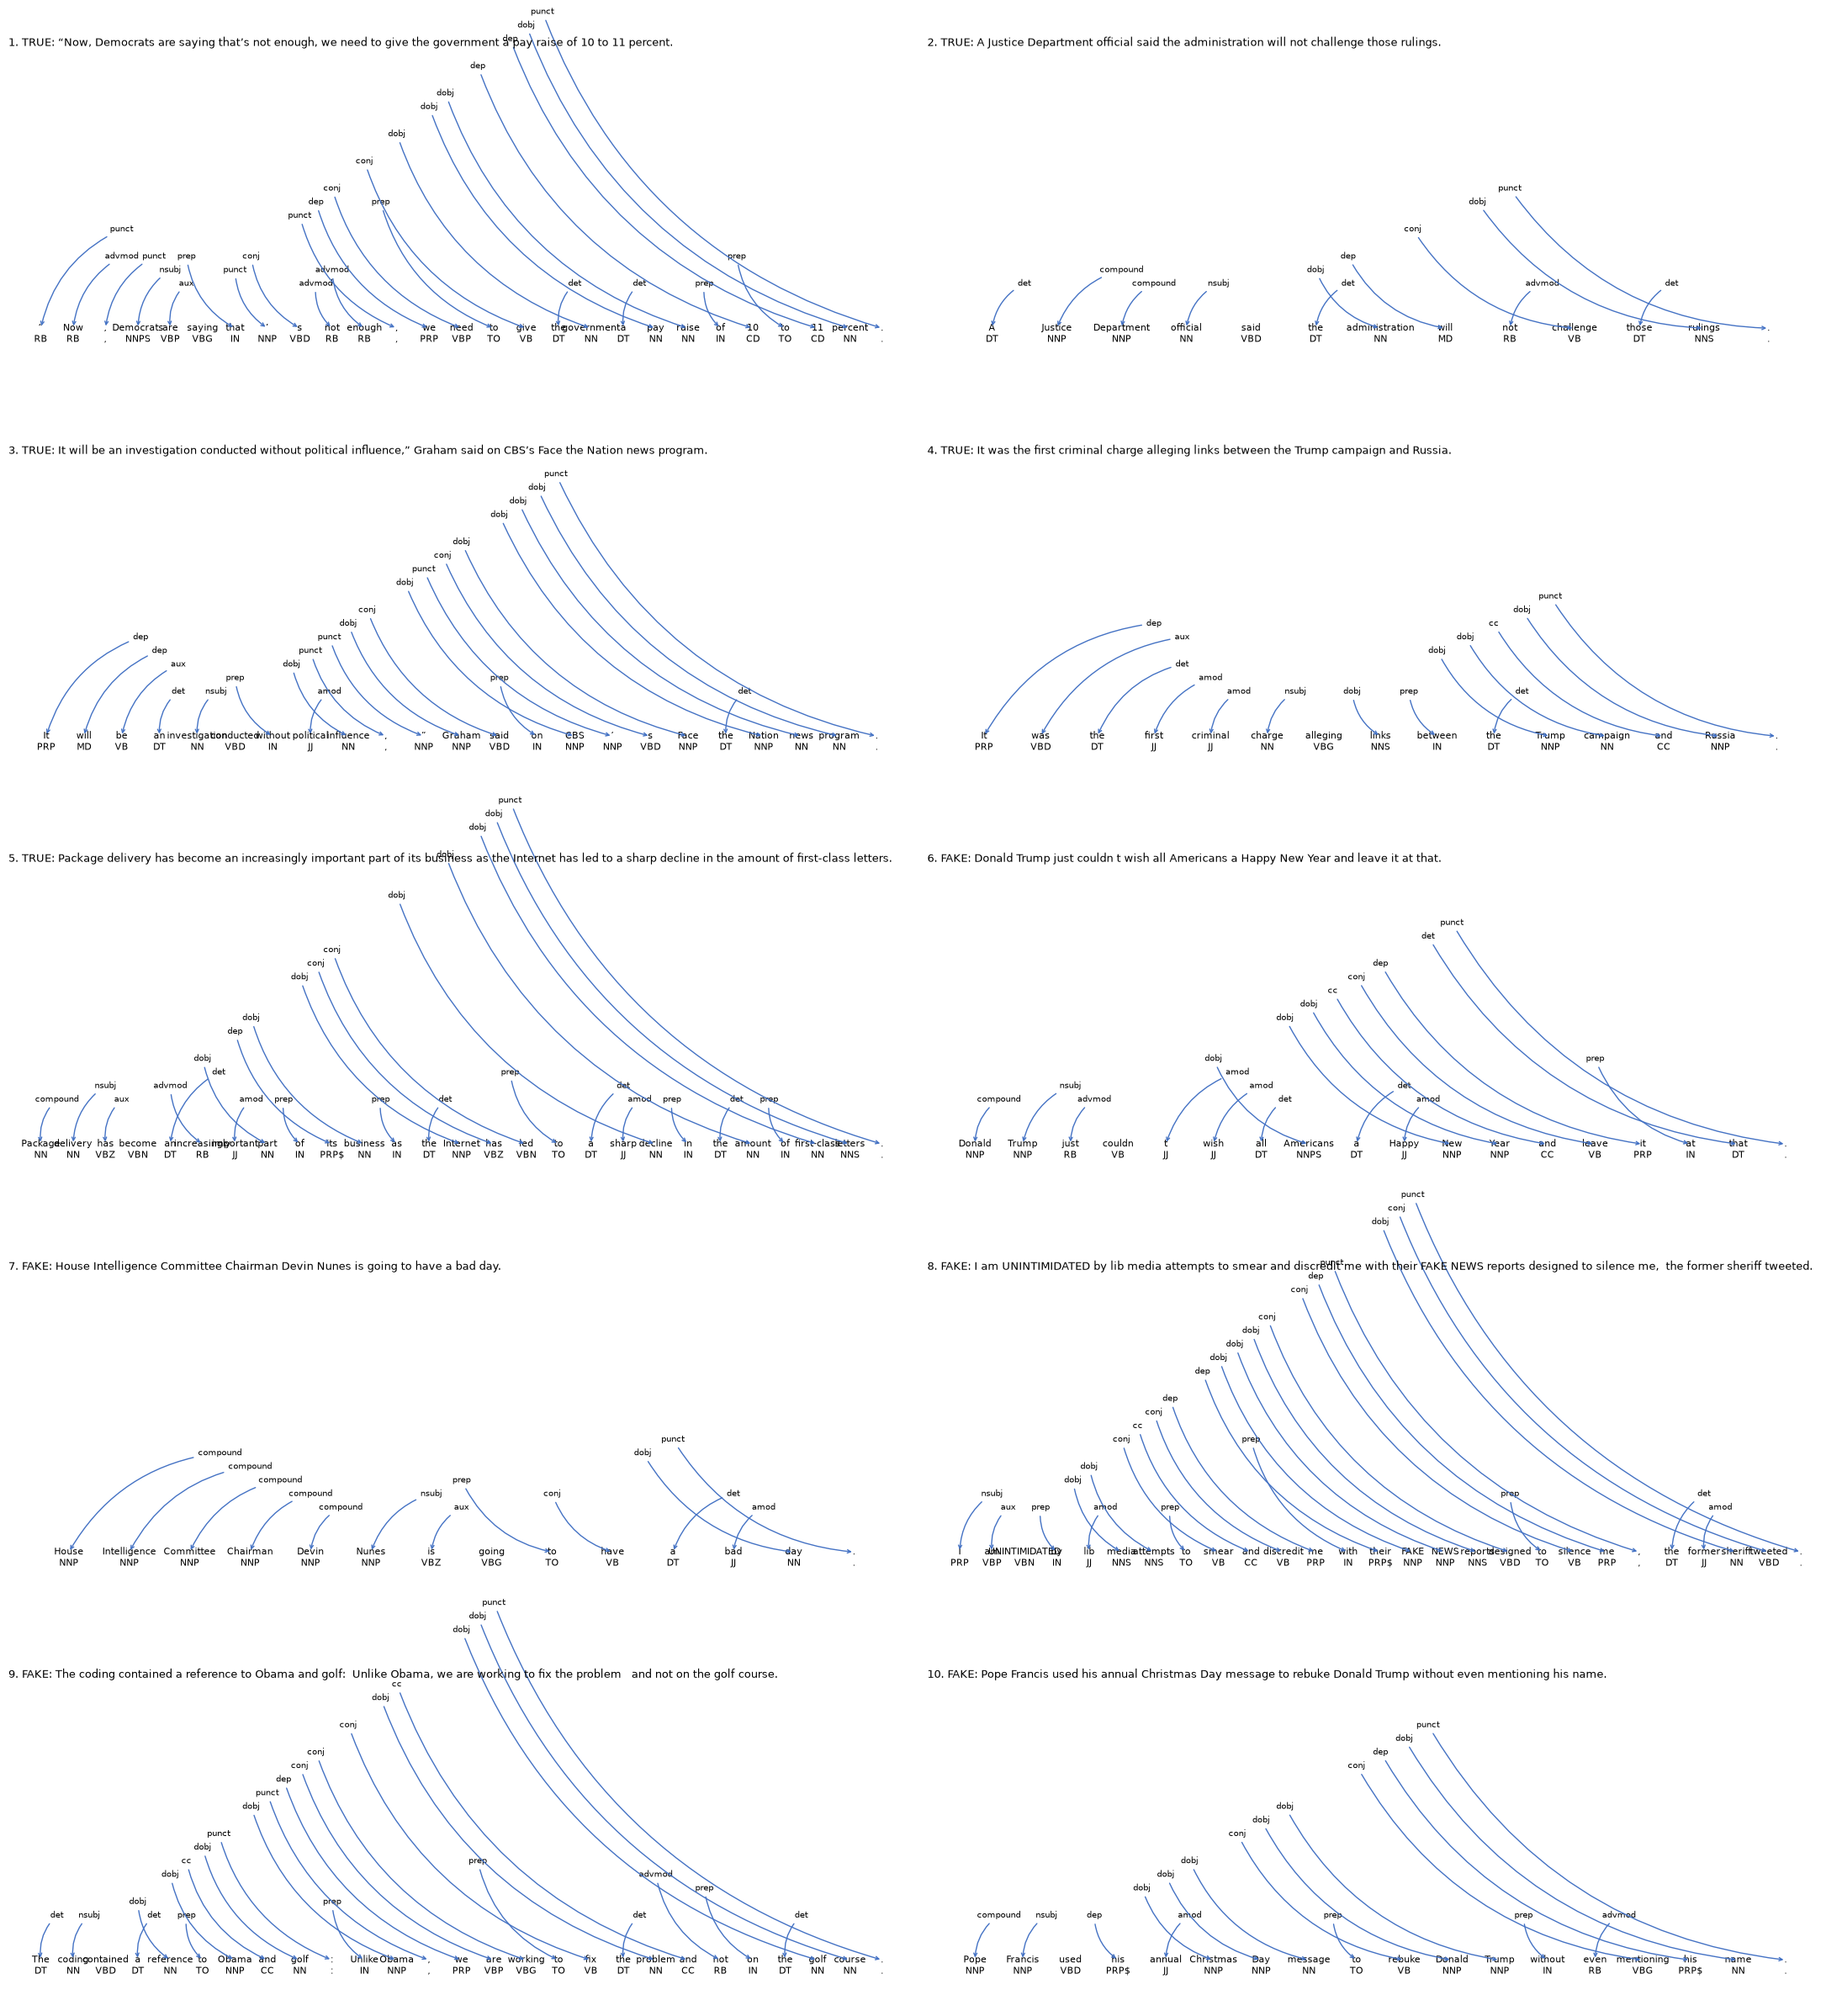

In [15]:
# Строим таблицы зависимостей для выбранных предложений.
selected_sentences = [
    (document_class, sentence)
    for document_class, sentences in medium_sentences.items()
    for sentence in sentences
]
dependency_trees = [
    build_dependency_tree(pos_tag(word_tokenize(sentence)))
    for _, sentence in selected_sentences
]

# Рисуем токены на одной оси и дуги от родителей к зависимым словам.
fig, axes = plt.subplots(5, 2, figsize=(22, 24))
for sentence_number, (axis, sentence_data, tree) in enumerate(
    zip(axes.flat, selected_sentences, dependency_trees), start=1
):
    document_class, sentence = sentence_data
    axis.set_title(
        f"{sentence_number}. {document_class}: {sentence}",
        fontsize=9, loc="left", wrap=True,
    )
    for row in tree.itertuples(index=False):
        axis.text(row.index, 0, f"{row.token}\n{row.pos}", ha="center", fontsize=8)
        if row.head >= 0:
            arc_height = 0.25 + 0.08 * abs(row.index - row.head)
            axis.annotate(
                row.relation, xy=(row.index, 0.08),
                xytext=((row.index + row.head) / 2, arc_height),
                ha="center", fontsize=7,
                arrowprops={
                    "arrowstyle": "->",
                    "connectionstyle": "arc3,rad=0.25",
                    "color": "#4472c4",
                },
            )
    axis.set_xlim(-1, len(tree))
    axis.set_ylim(-0.2, 1.7)
    axis.axis("off")
plt.tight_layout()
plt.show()

# 4. Разработка алгоритма извлечения паттернов

Для новостного корпуса извлекаем пары `[субъект + действие]`: находим связь `nsubj`, переходим к её вершине-глаголу и нормализуем оба элемента пары.

In [16]:
def extract_subject_action_pairs(
    dependency_tree: pd.DataFrame,
) -> list[tuple[str, str]]:
    """
    Извлекает пары подлежащего и сказуемого из дерева зависимостей.

    Parameters:
        dependency_tree (pd.DataFrame): Таблица синтаксических связей.

    Returns:
        list[tuple[str, str]]: Лемматизированные пары субъект-действие.

    Fallbacks:
        Возвращает пустой список, если связь nsubj не найдена.
    """
    # Обходим связи подлежащего и проверяем, что их вершиной служит глагол.
    extracted_pairs = []
    for subject_row in dependency_tree[
        dependency_tree["relation"] == "nsubj"
    ].itertuples(index=False):
        predicate_rows = dependency_tree[
            dependency_tree["index"] == subject_row.head
        ]
        if predicate_rows.empty:
            continue
        predicate_row = next(predicate_rows.itertuples(index=False))
        if not predicate_row.pos.startswith("VB"):
            continue

        # Лемматизация объединяет грамматические формы одной пары.
        subject = lemmatizer.lemmatize(subject_row.token.lower(), "n")
        action = lemmatizer.lemmatize(predicate_row.token.lower(), "v")
        extracted_pairs.append((subject, action))

    return extracted_pairs


# Проверяем алгоритм на десяти уже построенных деревьях.
pattern_preview_rows = []
for (document_class, sentence), tree in zip(
    selected_sentences, dependency_trees
):
    for subject, action in extract_subject_action_pairs(tree):
        pattern_preview_rows.append(
            (document_class, sentence, subject, action)
        )
display(
    pd.DataFrame(
        pattern_preview_rows,
        columns=["Класс", "Предложение", "Субъект", "Действие"],
    )
)

,Класс,Предложение,Субъект,Действие
0,TRUE,"“Now, Democrats are saying that’s not enough, ...",democrat,say
1,TRUE,A Justice Department official said the adminis...,official,say
2,TRUE,It will be an investigation conducted without ...,investigation,conduct
3,TRUE,It was the first criminal charge alleging link...,charge,allege
4,TRUE,Package delivery has become an increasingly im...,delivery,become
5,FAKE,Donald Trump just couldn t wish all Americans ...,trump,couldn
6,FAKE,House Intelligence Committee Chairman Devin Nu...,nunes,go
7,FAKE,I am UNINTIMIDATED by lib media attempts to sm...,i,unintimidated
8,FAKE,The coding contained a reference to Obama and ...,coding,contain
9,FAKE,Pope Francis used his annual Christmas Day mes...,francis,use


# 5. Анализ извлечённых паттернов

Для ресурсоёмкого синтаксического анализа используем воспроизводимую сбалансированную подвыборку до 1000 документов каждого класса. Это сохраняет сопоставимость классов и не подменяет рассчитанное выше POS-распределение всего корпуса.

,Субъект,Действие,Всего,TRUE,FAKE
0,’,s,777,622,155
1,he,say,281,211,70
2,it,’,259,167,92
3,i,’,225,162,63
4,i,think,213,142,71
5,it,s,203,21,182
6,we,’,138,107,31
7,i,don,129,72,57
8,it,be,113,49,64
9,you,’,94,66,28


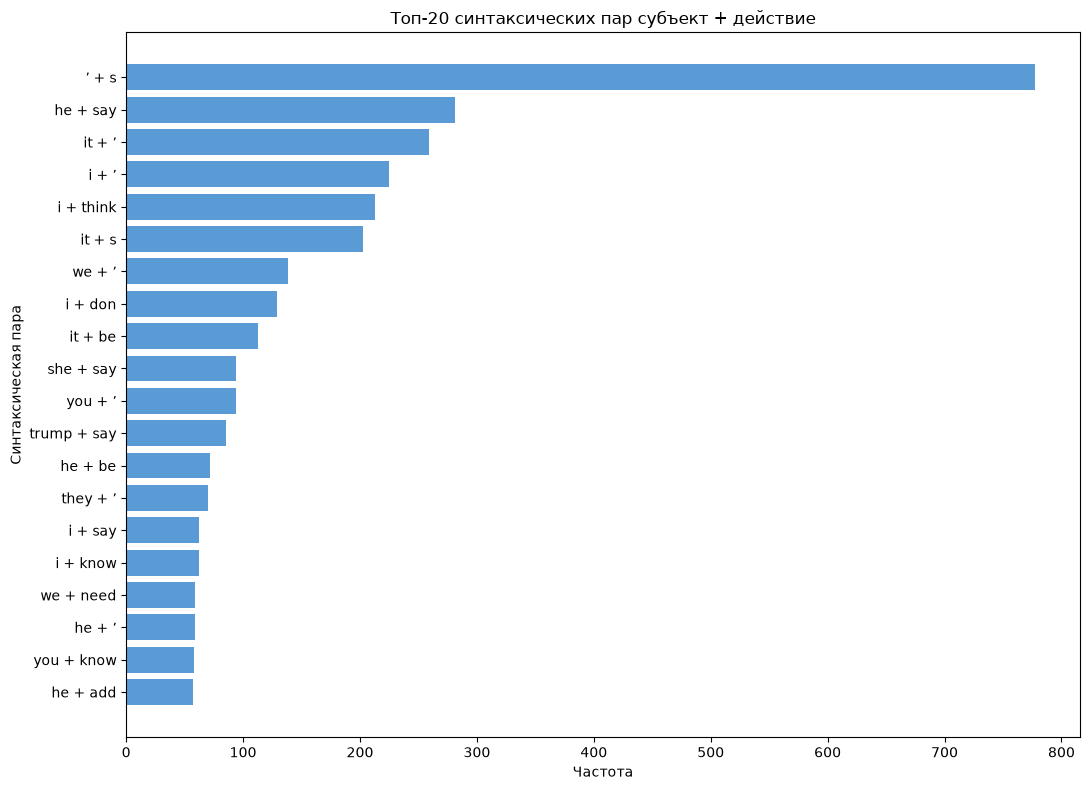

In [17]:
# Формируем одинаковые по размеру случайные подвыборки классов.
pattern_source_df = pd.concat(
    [
        class_df.sample(
            n=min(PATTERN_DOCUMENTS_PER_CLASS, len(class_df)),
            random_state=RANDOM_STATE,
        )
        for _, class_df in news_df.groupby("class")
    ],
    ignore_index=True,
)
pattern_counts = Counter()
pattern_counts_by_class = {"TRUE": Counter(), "FAKE": Counter()}

# Извлекаем пары из предложений умеренной длины, где эвристики устойчивее.
for document_class, text in pattern_source_df[["class", "text"]].itertuples(
    index=False
):
    for sentence in sent_tokenize(text):
        tokens = word_tokenize(sentence)
        if not 3 <= sum(token.isalpha() for token in tokens) <= 40:
            continue
        tree = build_dependency_tree(pos_tag(tokens))
        pairs = extract_subject_action_pairs(tree)
        pattern_counts.update(pairs)
        pattern_counts_by_class[document_class].update(pairs)

# Выводим топ-20 пар и их распределение между классами.
top_patterns_df = pd.DataFrame(
    [
        (
            subject, action, frequency,
            pattern_counts_by_class["TRUE"][(subject, action)],
            pattern_counts_by_class["FAKE"][(subject, action)],
        )
        for (subject, action), frequency in pattern_counts.most_common(20)
    ],
    columns=["Субъект", "Действие", "Всего", "TRUE", "FAKE"],
)
display(top_patterns_df)

# Визуализируем частоты наиболее популярных пар.
plot_patterns_df = top_patterns_df.sort_values("Всего")
plt.figure(figsize=(11, 8))
plt.barh(
    plot_patterns_df["Субъект"] + " + " + plot_patterns_df["Действие"],
    plot_patterns_df["Всего"], color="#5b9bd5",
)
plt.title("Топ-20 синтаксических пар субъект + действие")
plt.xlabel("Частота")
plt.ylabel("Синтаксическая пара")
plt.tight_layout()
plt.show()

После выполнения ячеек здесь следует кратко описать, какие пары отражают новостную тематику и различия TRUE/FAKE, а какие появились из-за ошибок rule-based разбора.

# 6. Разрешение анафоры

Поскольку корпус англоязычный, рассматриваем эквиваленты местоимений `он`, `она`, `они`, `это`: `he`, `she`, `they`, `it`, `this`. Алгоритм согласует кандидатов по числу, учитывает доступный род и выбирает ближайшее предшествующее существительное.

In [18]:
def resolve_anaphora(text: str) -> str:
    """
    Заменяет местоимения третьего лица ближайшими согласованными существительными.

    Parameters:
        text (str): Английский текст с контекстом для поиска антецедента.

    Returns:
        str: Текст с выполненными rule-based заменами местоимений.

    Fallbacks:
        Местоимение остаётся без изменения, если подходящего кандидата нет.
    """
    # Размечаем контекст целиком и накапливаем предшествующие существительные.
    tokens = word_tokenize(text)
    tagged_tokens = pos_tag(tokens)
    noun_candidates = []
    resolved_tokens = []

    for token_index, (token, tag) in enumerate(tagged_tokens):
        token_lower = token.lower()
        if tag.startswith("NN"):
            number = "plural" if tag in {"NNS", "NNPS"} else "singular"
            if token_lower in MASCULINE_NOUNS:
                gender = "masculine"
            elif token_lower in FEMININE_NOUNS:
                gender = "feminine"
            elif tag.startswith("NNP"):
                gender = "unknown"
            else:
                gender = "neutral"
            noun_candidates.append((token, number, gender, token_index, tag))

        replacement = token
        if token_lower in PRONOUN_FEATURES and (
            tag.startswith("PRP") or token_lower == "this"
        ):
            required_number, required_gender = PRONOUN_FEATURES[token_lower]
            compatible_candidates = [
                candidate
                for candidate in noun_candidates
                if candidate[1] == required_number
                and (
                    required_gender == "unknown"
                    or candidate[2] in {required_gender, "unknown"}
                )
                and token_index - candidate[3] <= 60
            ]

            # Для it/this отдаём приоритет нарицательным, а не личным именам.
            if required_gender == "neutral":
                neutral_candidates = [
                    candidate
                    for candidate in compatible_candidates
                    if not candidate[4].startswith("NNP")
                ]
                compatible_candidates = neutral_candidates or compatible_candidates

            if compatible_candidates:
                replacement = compatible_candidates[-1][0]
                if token[0].isupper():
                    replacement = replacement.capitalize()

        resolved_tokens.append(replacement)

    # Восстанавливаем читаемые пробелы возле пунктуации и притяжательных форм.
    resolved_text = " ".join(resolved_tokens)
    resolved_text = re.sub(r"\s+([.,!?;:%)])", r"\1", resolved_text)
    resolved_text = re.sub(r"([(])\s+", r"\1", resolved_text)
    resolved_text = re.sub(r"\s+('s|n't)\b", r"\1", resolved_text)
    return resolved_text

Находим десять коротких контекстов с целевыми местоимениями и сопоставляем исходный и преобразованный варианты.

In [19]:
# Отбираем пары соседних предложений, чтобы антецедент мог находиться слева.
anaphora_contexts = []
for document_class, text in news_df[["class", "text"]].itertuples(
    index=False
):
    sentences = sent_tokenize(text)
    for sentence_index in range(1, len(sentences)):
        current_tokens = [
            token.lower() for token in word_tokenize(sentences[sentence_index])
        ]
        if (
            set(current_tokens) & set(PRONOUN_FEATURES)
            and len(current_tokens) <= 35
        ):
            context = " ".join(
                [sentences[sentence_index - 1], sentences[sentence_index]]
            )
            anaphora_contexts.append((document_class, context))
            break
    if len(anaphora_contexts) == 10:
        break

# Сравниваем исходный контекст с результатом разрешения анафоры.
anaphora_comparison_df = pd.DataFrame(
    [
        (document_class, context, resolve_anaphora(context))
        for document_class, context in anaphora_contexts
    ],
    columns=["Класс", "Исходный контекст", "После замены"],
)
display(anaphora_comparison_df)

,Класс,Исходный контекст,После замены
0,TRUE,... Eventually you run out of other people’s m...,... Eventually you run out of other people ’ s...
1,TRUE,A Justice Department official said the adminis...,A Justice Department official said the adminis...
2,TRUE,"Lindsey Graham, who serves on the Senate armed...","Lindsey Graham, who serves on the Senate armed..."
3,TRUE,"Papadopoulos, a Chicago-based international en...","Papadopoulos, a Chicago-based international en..."
4,TRUE,President Donald Trump called on the U.S. Post...,President Donald Trump called on the U.S. Post...
5,TRUE,“There’s been no collusion. But I think he’s g...,“ There ’ s been no collusion. But I think ’ ’...
6,TRUE,Moore declined to concede defeat even after Tr...,Moore declined to concede defeat even after Tr...
7,TRUE,Those states are generally Democratic leaning....,Those states are generally Democratic leaning....
8,TRUE,"“Protest really should be funny,” Strong told ...","“ Protest really should be funny, ” Strong tol..."
9,TRUE,The chairman of the Virginia Board of Election...,The chairman of the Virginia Board of Election...


Rule-based алгоритм прозрачен и учитывает число, род и расстояние, но английские имена не кодируют род морфологически. Поэтому кандидаты с неизвестным родом допускаются как запасной вариант, а итоговые замены необходимо оценивать по выведенным контекстам.